In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import yaml
import datetime

from src.model import Custom_ResNet50, Custom_DenseNet121, ModelWrapper
from src.preprocessing import get_hilbert_index, hilbert_ravel, pipeline
import src.gradcam

# Get and View Grad-CAMs

This tool allows for easy viewing of the Grad-CAM image masks which highlight the regions of the image which the model finds the most important in its decision-making

#### Main Model Parameters

```
model_type: The model architecture parameter ("ResNet50" or "DenseNet121")
dim: The input image dimension parameter (224 or 384)
enhanced: Use models trained on enhanced images (True or False

row_idx: The image row index from the input .csv
```

#### Other Variables

```
save_combined_gradcam_fig: Save a combined plot containing all gradcam images
save_separate_gradcams: Save individual gradcam images (5x total)
```

In [2]:
### Use test data frame
df = pd.read_csv("data/processed_data/test_df.csv")

print(f"Choose a row index from 0 to {len(df) - 1}")

Choose a row index from 0 to 39370


In [3]:
row_idx = 39370

In [4]:
### Extract the associated path
img_path = df.loc[row_idx, "source_file_path"]

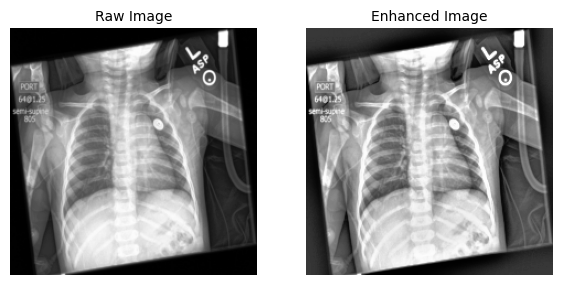

In [5]:
# View the selected image
fig,ax = plt.subplots(1,2, figsize=(7,4))

imgs, img_enhanceds = pipeline(img_path, [224])
ax[0].imshow(imgs[0], cmap="gray")
ax[0].axis("off")
ax[0].set_title("Raw Image", fontsize=10)
#
ax[1].imshow(img_enhanceds[0], cmap="gray")
ax[1].axis("off")
ax[1].set_title("Enhanced Image", fontsize=10)

plt.show()

In [6]:
### Set the save folder here
save_folder = f"Query_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}"

In [7]:
### Save one combined figure of grad-CAMs per model to:
    # results/gradcam/save_folder/
save_combined_gradcam_fig = True

### Save individual gradcam overlay images (one per model, per condition) to:
    # results/gradcam/save_folder/
save_separate_gradcams = True

In [8]:
### Check if the save folder exists - create it otherwise
if (save_combined_gradcam_fig) or (save_separate_gradcams):
    os.makedirs(f"results/gradcam/{save_folder}", exist_ok=True)

## Viewing grad-CAMs of a custom model/csv

**csv_path**: The filepath to the .csv containing the predictions. This is either manually specified or automatically set to:
* ```f"results/{model_type}_BASE{dim}_ENHANCED_test_withPredictionsAndConfidences.csv"``` for enhanced images or
* ```f"results/{model_type}_BASE{dim}_test_withPredictionsAndConfidences.csv"``` for raw images

**model_path**: The filepath to the .pth containing the trained model. This is either manually specified or automatically set to:
* ```f"models/{model_type}_BASE{dim}_ENHANCED.pth"``` for enhanced images or
* ```f"models/{model_type}_BASE{dim}.pth"``` for raw images

Displaying custom results
Combined figure saved to results/gradcam/CustomQuery_20250314_031400/RAW_DenseNet121_BASE224_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_4_Pleural Effusion_noTitle.png


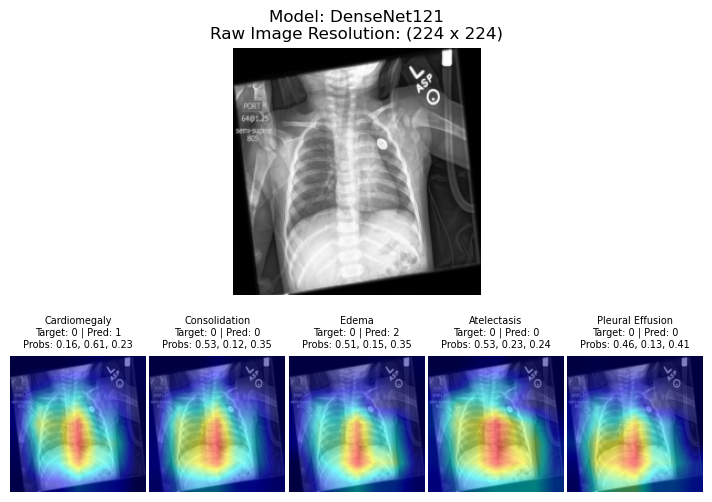

In [9]:
# VIEW CUSTOM RESULTS/MODEL
view_gradcams_for_custom_configuration = True

if view_gradcams_for_custom_configuration:
    print("Displaying custom results")
    
    # Enter parameters - ensure that the model type, dimension, and enhanced parameters match the csv/model paths
    model_type="DenseNet121"
    dim=224
    enhanced=False
    row_idx=row_idx
    #
    csv_path0 = "results/DenseNet121_BASE224_test_withPredictionsAndConfidences2.csv" # example: "results/DenseNet121_BASE224_test_withPredictionsAndConfidences.csv"
    model_path0 = "models/DenseNet121_BASE224.pth" # example: "models/ResNet50_BASE224.pth"
    save_folder0 = f"CustomQuery_{datetime.datetime.now().strftime("%Y%m%d_%H%M%S")}"

    ### Check if the save folder exists - create it otherwise
    if (save_combined_gradcam_fig) or (save_separate_gradcams):
        os.makedirs(f"results/gradcam/{save_folder0}", exist_ok=True)
    
    ##### Wrap into a kwargs dict and get images
    wrapper_kwargs = dict(
        model_type=model_type, dim=dim, enhanced=enhanced, row_idx=row_idx, csv_path=csv_path0, model_path=model_path0
    )
    
    #####
    gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(**wrapper_kwargs)
    fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                           save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                           save_folder=save_folder0,
                                                           **overlay_kwargs)
#
    #
    if save_separate_gradcams:
        src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                           patientID=patientID, 
                                           save_folder=save_folder, 
                                           **{**wrapper_kwargs, **overlay_kwargs})

## View Grad-CAM for the trained models

In [10]:
### Load wrapper_kwargs
with open("config/wrapper_kwargs.yaml", "r") as params:
    wrapper_kwargs = yaml.safe_load(params)

#### RAW IMAGES, RESNET50, 224x224

Combined figure saved to results/gradcam/Query_20250314_031400/RAW_ResNet50_BASE224_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE224W_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE224W_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE224W_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE224W_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE224W_gradcam_condition_4_Pleural Effusion_noTitle.png


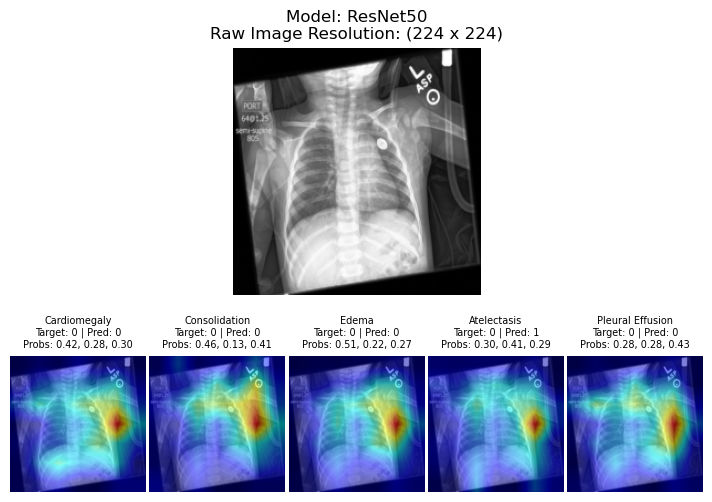

In [11]:
wrapper_key = "wrapper_kwargs0"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### ENHANCED IMAGES, RESNET50, 224x224

{'dim': 224, 'enhanced': True, 'model_type': 'ResNet50'}
Combined figure saved to results/gradcam/Query_20250314_031400/ENHANCED_ResNet50_BASE224_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE224_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE224_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE224_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE224_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE224_gradcam_condition_4_Pleural Effusion_noTitle.png


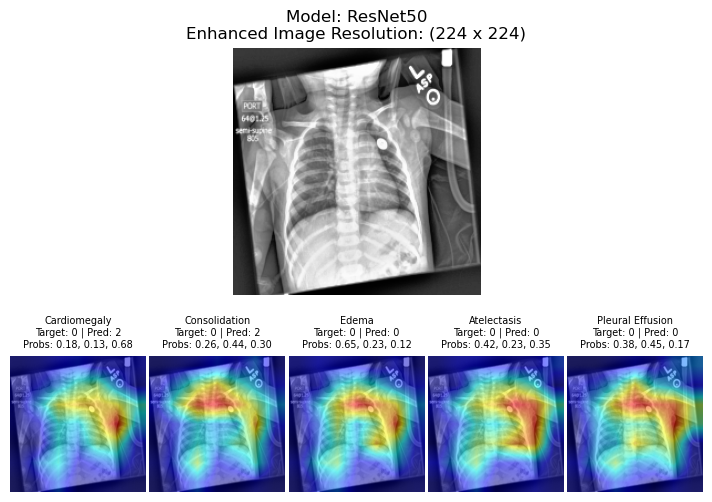

In [12]:
wrapper_key = "wrapper_kwargs1"
print(wrapper_kwargs[wrapper_key])
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### RAW IMAGES, RESNET50, 384x384

Combined figure saved to results/gradcam/Query_20250314_031400/RAW_ResNet50_BASE384_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE384W_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE384W_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE384W_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE384W_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE384W_gradcam_condition_4_Pleural Effusion_noTitle.png


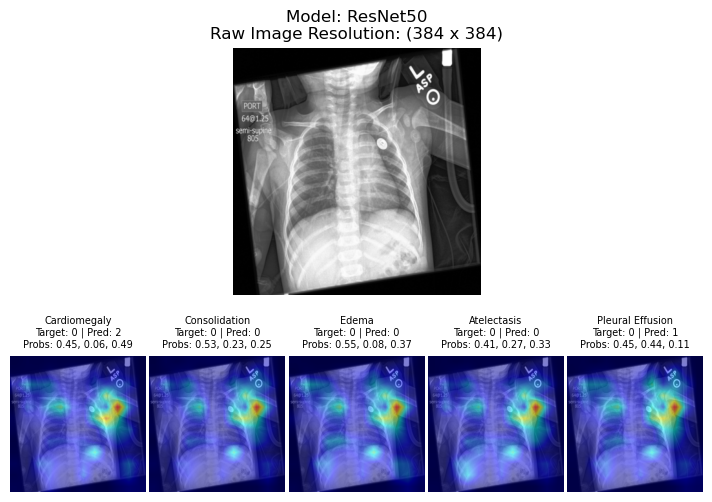

In [13]:
wrapper_key = "wrapper_kwargs2"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### ENHANCED IMAGES, RESNET50, 384x384

Combined figure saved to results/gradcam/Query_20250314_031400/ENHANCED_ResNet50_BASE384_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE384_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE384_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE384_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE384_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE384_gradcam_condition_4_Pleural Effusion_noTitle.png


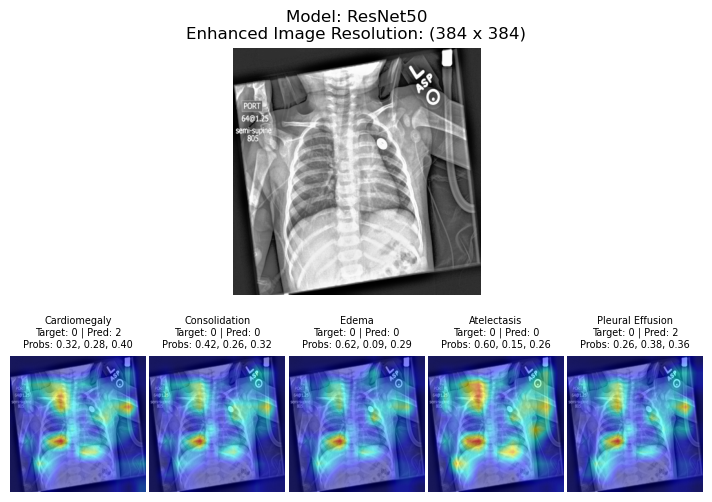

In [14]:
wrapper_key = "wrapper_kwargs3"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### RAW IMAGES, RESNET50, 512x512

Combined figure saved to results/gradcam/Query_20250314_031400/RAW_ResNet50_BASE512_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE512W_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE512W_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE512W_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE512W_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_ResNet50_BASE512W_gradcam_condition_4_Pleural Effusion_noTitle.png


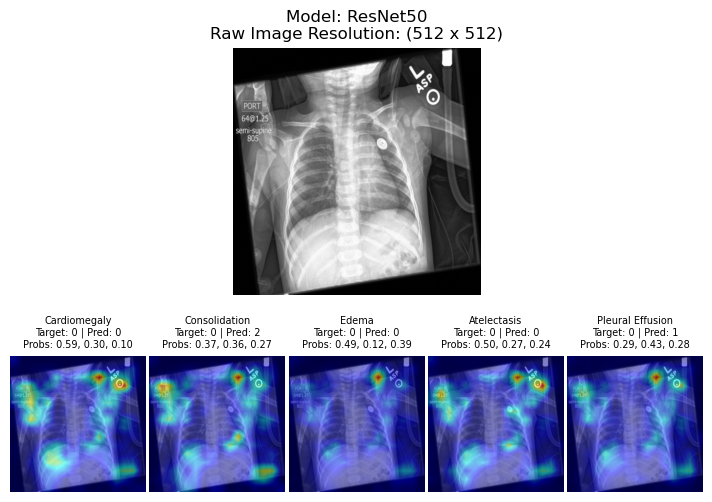

In [15]:
wrapper_key = "wrapper_kwargs4"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### ENHANCED IMAGES, RESNET50, 512x512

Combined figure saved to results/gradcam/Query_20250314_031400/ENHANCED_ResNet50_BASE512_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE512_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE512_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE512_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE512_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_ResNet50_BASE512_gradcam_condition_4_Pleural Effusion_noTitle.png


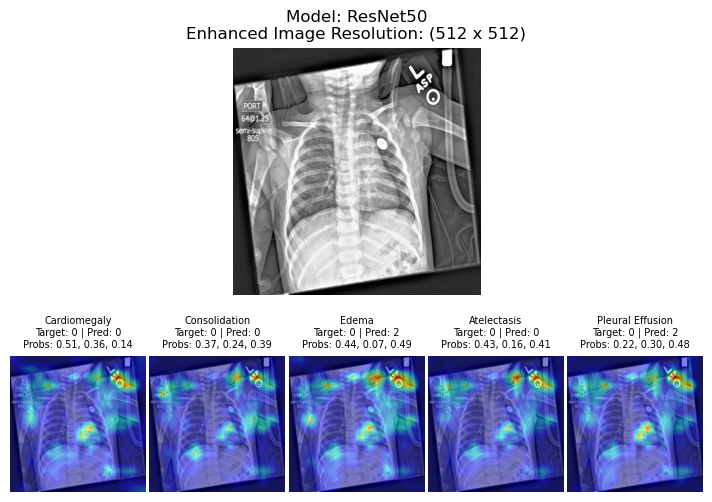

In [16]:
wrapper_key = "wrapper_kwargs5"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### RAW IMAGES, DENSENET, 224x224

Combined figure saved to results/gradcam/Query_20250314_031400/RAW_DenseNet121_BASE224_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE224W_gradcam_condition_4_Pleural Effusion_noTitle.png


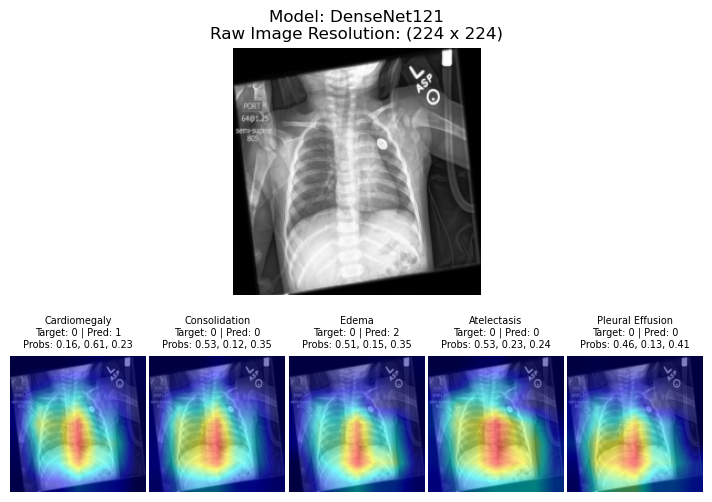

In [17]:
wrapper_key = "wrapper_kwargs6"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### ENHANCED IMAGES, DENSENET, 224x224

Combined figure saved to results/gradcam/Query_20250314_031400/ENHANCED_DenseNet121_BASE224_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE224_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE224_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE224_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE224_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE224_gradcam_condition_4_Pleural Effusion_noTitle.png


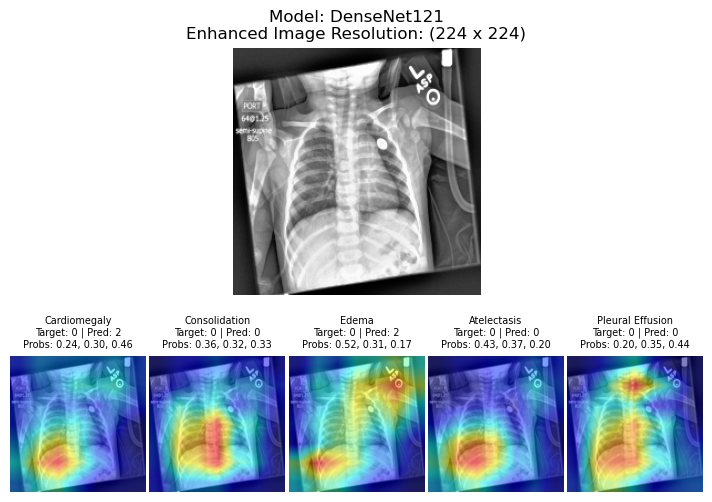

In [18]:
wrapper_key = "wrapper_kwargs7"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### RAW IMAGES, DENSENET, 384x384

Combined figure saved to results/gradcam/Query_20250314_031400/RAW_DenseNet121_BASE384_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE384W_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE384W_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE384W_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE384W_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE384W_gradcam_condition_4_Pleural Effusion_noTitle.png


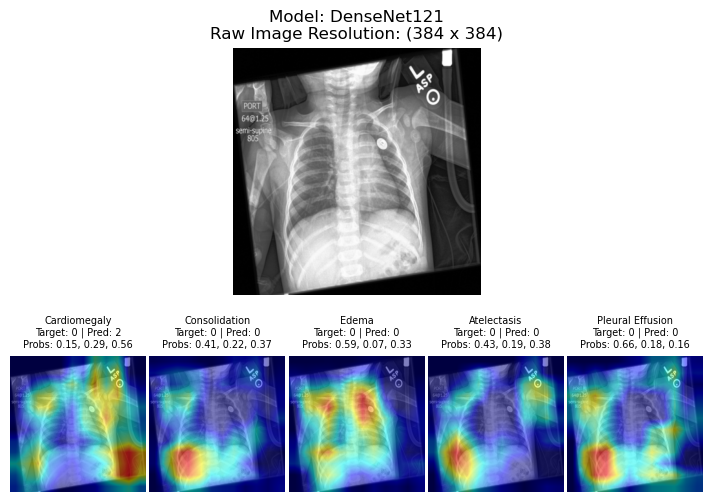

In [19]:
wrapper_key = "wrapper_kwargs8"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### ENHANCED IMAGES, DENSENET, 384x384

Combined figure saved to results/gradcam/Query_20250314_031400/ENHANCED_DenseNet121_BASE384_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE384_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE384_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE384_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE384_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE384_gradcam_condition_4_Pleural Effusion_noTitle.png


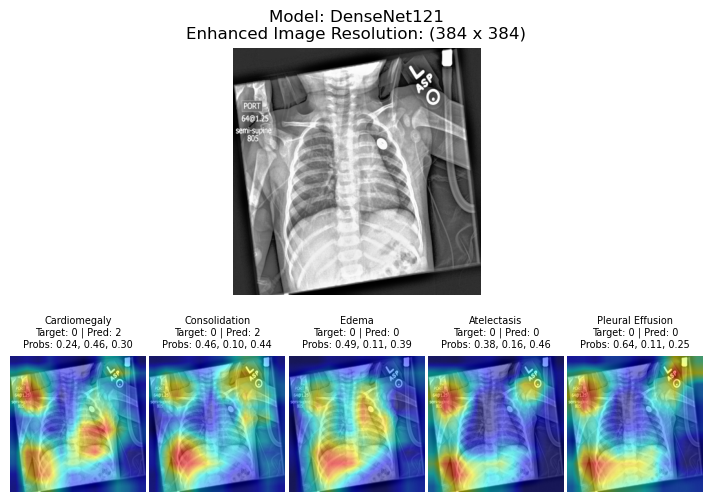

In [20]:
wrapper_key = "wrapper_kwargs9"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### RAW IMAGES, DENSENET, 512x512

Combined figure saved to results/gradcam/Query_20250314_031400/RAW_DenseNet121_BASE512_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE512W_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE512W_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE512W_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE512W_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_RAW_DenseNet121_BASE512W_gradcam_condition_4_Pleural Effusion_noTitle.png


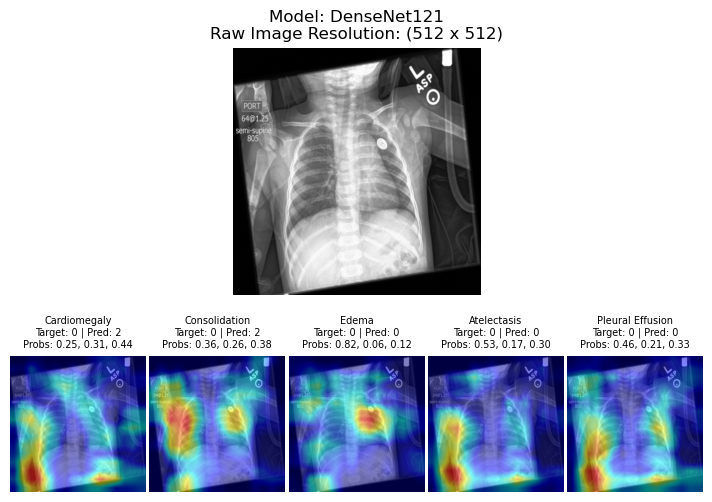

In [21]:
wrapper_key = "wrapper_kwargs10"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})

#### ENHANCED IMAGES, DENSENET, 512x512

Combined figure saved to results/gradcam/Query_20250314_031400/ENHANCED_DenseNet121_BASE512_allGradcams.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE512_gradcam_condition_0_Cardiomegaly_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE512_gradcam_condition_1_Consolidation_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE512_gradcam_condition_2_Edema_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE512_gradcam_condition_3_Atelectasis_noTitle.png
Individual gradcam image saved to results/gradcam/Query_20250314_031400/patient64540_ENHANCED_DenseNet121_BASE512_gradcam_condition_4_Pleural Effusion_noTitle.png


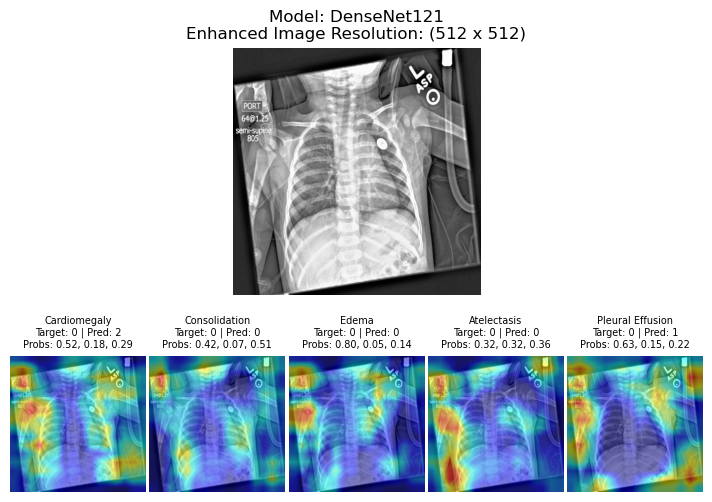

In [22]:
wrapper_key = "wrapper_kwargs11"
#
gradcam_masks, gradcam_images, patientID, overlay_kwargs = src.gradcam.wrapper_generate_gradcams(row_idx=row_idx, 
                                                                                                 **wrapper_kwargs[wrapper_key])
fig, axes = src.gradcam.plot_gradcam_overlays_gridspec(gradcam_images=gradcam_images, 
                                                       save_combined_gradcam_fig=save_combined_gradcam_fig, 
                                                       save_folder=save_folder,
                                                       **overlay_kwargs)
#
if save_separate_gradcams:
    src.gradcam.save_separate_gradcams(gradcam_images=gradcam_images, 
                                       patientID=patientID, 
                                       save_folder=save_folder, 
                                       **{**wrapper_kwargs[wrapper_key], **overlay_kwargs})